In [154]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns
import plotly.io as pio
pio.renderers.default = 'iframe'

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

In [155]:
PATH_DIRECTORIO_DATOS = "../data"

In [156]:
PATH_DATASET_PRACTICA = f"{PATH_DIRECTORIO_DATOS}/dataset_practica_final.csv"

In [157]:
df_hoteles = pd.read_csv(PATH_DATASET_PRACTICA)

In [158]:
df_hoteles.info

<bound method DataFrame.info of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27  

In [159]:
df_hoteles.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [160]:
df_hoteles.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [161]:
df_hoteles.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [162]:
df_hoteles.duplicated().sum()

31994

In [163]:
df_hoteles.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 119390, dtype: bool

In [164]:
duplicated_todas = df_hoteles[df_hoteles.duplicated(keep = False)]
duplicated_todas

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119372,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04


In [165]:
duplicated_todas.sort_values(by=list(df_hoteles.columns))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11602,Resort Hotel,1,471,2017,May,20,20,2,5,2,...,Non Refund,96.0,NaN,0,Transient,47.0,0,0,Canceled,2017-05-03
11603,Resort Hotel,1,471,2017,May,20,20,2,5,2,...,Non Refund,96.0,NaN,0,Transient,47.0,0,0,Canceled,2017-05-03
11605,Resort Hotel,1,471,2017,May,20,20,2,5,2,...,Non Refund,96.0,NaN,0,Transient,47.0,0,0,Canceled,2017-05-03
11606,Resort Hotel,1,471,2017,May,20,20,2,5,2,...,Non Refund,96.0,NaN,0,Transient,47.0,0,0,Canceled,2017-05-03


In [166]:
df_hoteles[df_hoteles["customer_type"] == "Transient-Party"].count()


hotel                             25124
is_canceled                       25124
lead_time                         25124
arrival_date_year                 25124
arrival_date_month                25124
arrival_date_week_number          25124
arrival_date_day_of_month         25124
stays_in_weekend_nights           25124
stays_in_week_nights              25124
adults                            25124
children                          25120
babies                            25124
meal                              25124
country                           25082
market_segment                    25124
distribution_channel              25124
is_repeated_guest                 25124
previous_cancellations            25124
previous_bookings_not_canceled    25124
reserved_room_type                25124
assigned_room_type                25124
booking_changes                   25124
deposit_type                      25124
agent                             20625
company                            2591


In [167]:
duplicated_todas[duplicated_todas["customer_type"] == "Transient-Party"].count()

hotel                             16711
is_canceled                       16711
lead_time                         16711
arrival_date_year                 16711
arrival_date_month                16711
arrival_date_week_number          16711
arrival_date_day_of_month         16711
stays_in_weekend_nights           16711
stays_in_week_nights              16711
adults                            16711
children                          16711
babies                            16711
meal                              16711
country                           16699
market_segment                    16711
distribution_channel              16711
is_repeated_guest                 16711
previous_cancellations            16711
previous_bookings_not_canceled    16711
reserved_room_type                16711
assigned_room_type                16711
booking_changes                   16711
deposit_type                      16711
agent                             14340
company                            1254


<Axes: xlabel='deposit_type', ylabel='Count'>

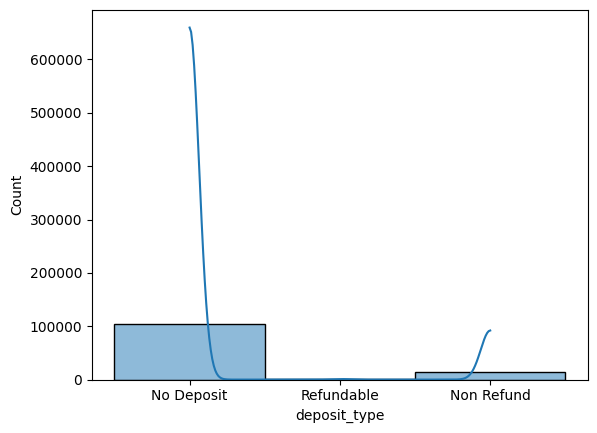

In [168]:
sns.histplot(df_hoteles, x = "deposit_type", kde=True)

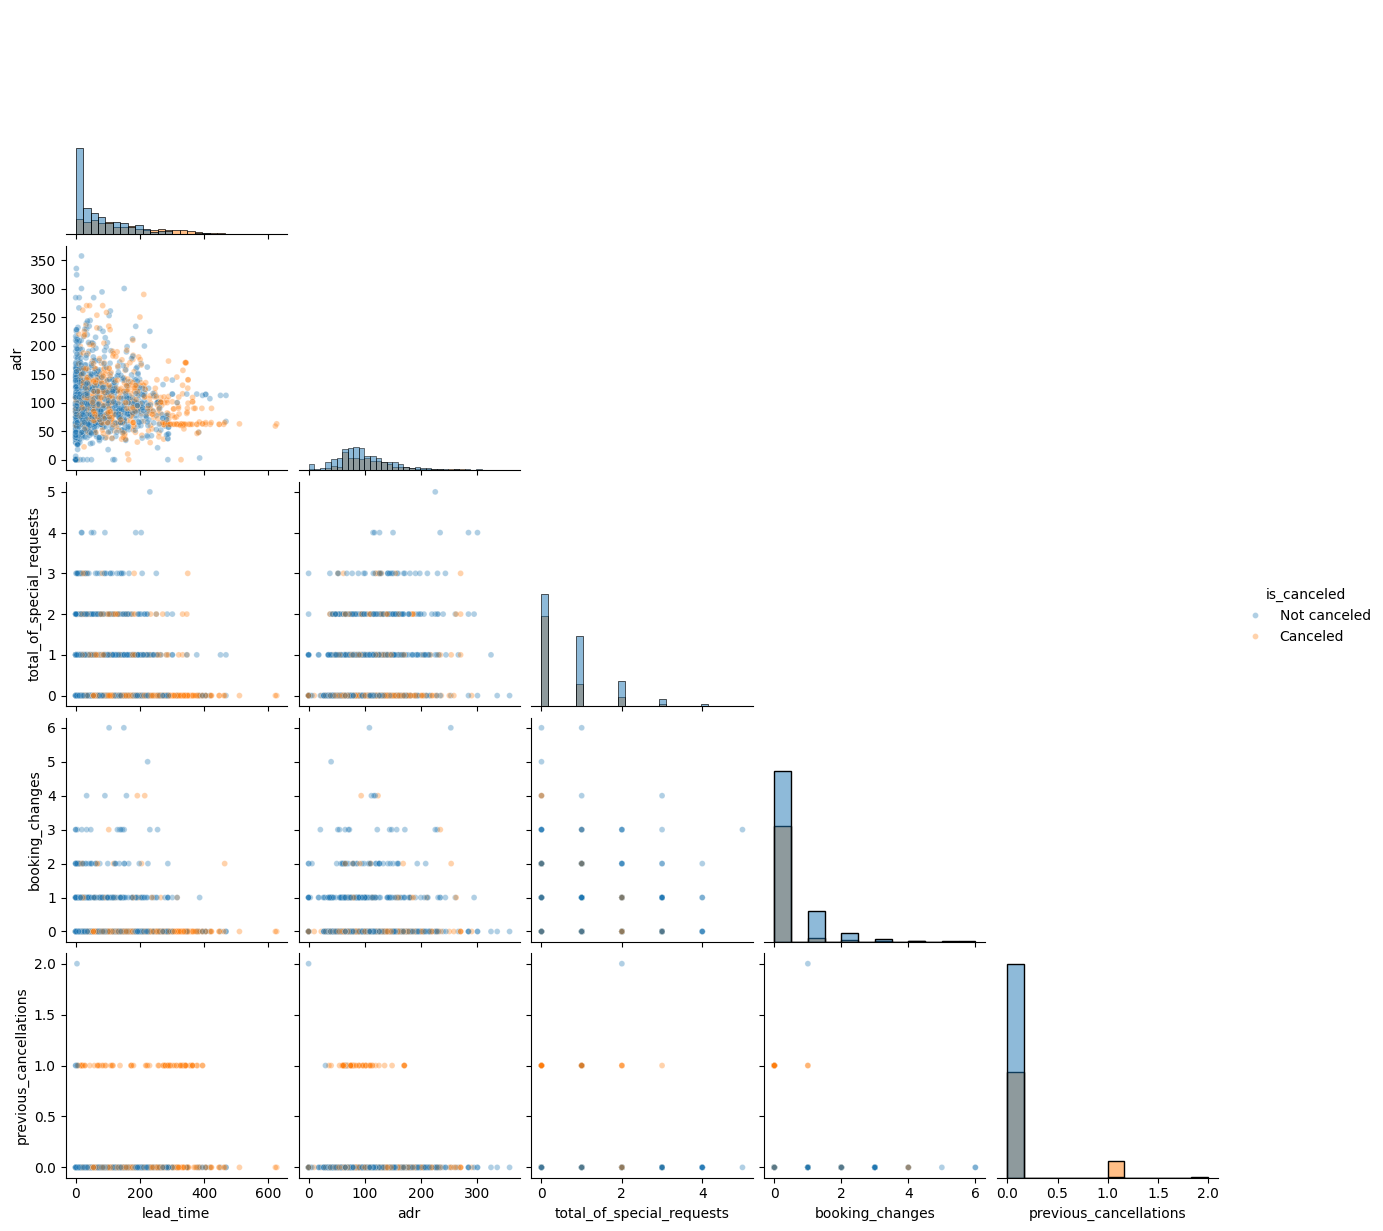

In [169]:
cols = [
    "lead_time",
    "adr",
    "total_of_special_requests",
    "booking_changes",
    "previous_cancellations",
    "is_canceled"
]

df_plot = df_hoteles[cols].dropna().loc[lambda df: df["previous_cancellations"] < 10].sample(1500, random_state=42).copy()
df_plot["is_canceled"] = df_plot["is_canceled"].map({0: "Not canceled", 1: "Canceled"})

sns.pairplot(
    df_plot,
    hue="is_canceled",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 18}
)

In [170]:
fig = px.scatter(data_frame=df_hoteles.loc[lambda df: df["adr"] < 2000], y="adr", x="lead_time", title="prueba")
fig.show(renderer='vscode')

In [171]:
df_hoteles_canceled = df_hoteles[df_hoteles["is_canceled"] == 1]

In [172]:
df_hoteles_canceled.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,44224.0,1.000000,0.000000,1.0,1.000,1.0,1.00,1.0
lead_time,44224.0,144.848815,118.624829,0.0,48.000,113.0,214.00,629.0
arrival_date_year,44224.0,2016.171920,0.714557,2015.0,2016.000,2016.0,2017.00,2017.0
arrival_date_week_number,44224.0,27.309696,13.083155,1.0,17.000,27.0,38.00,53.0
arrival_date_day_of_month,44224.0,15.728066,8.787969,1.0,8.000,16.0,23.00,31.0
stays_in_weekend_nights,44224.0,0.925267,1.007468,0.0,0.000,1.0,2.00,16.0
stays_in_week_nights,44224.0,2.561912,1.878296,0.0,1.000,2.0,3.00,40.0
adults,44224.0,1.901728,0.678038,0.0,2.000,2.0,2.00,55.0
children,44220.0,0.106513,0.411352,0.0,0.000,0.0,0.00,10.0
babies,44224.0,0.003821,0.062429,0.0,0.000,0.0,0.00,2.0


In [173]:
df_hoteles_canceled["reservation_status"].value_counts()

reservation_status
Canceled    43017
No-Show      1207
Name: count, dtype: int64

In [174]:
df_hoteles.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [175]:
df_hoteles_preprocessed = df_hoteles.drop(columns=["reservation_status", "reservation_status_date"])
df_hoteles_preprocessed.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0


In [176]:
df_hoteles_preprocessed.children.value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [177]:
df_hoteles_preprocessed.children.isna().sum()

4

In [178]:
df_hoteles_preprocessed.children.isna().sum()
df_hoteles_preprocessed["children"] = df_hoteles_preprocessed["children"].fillna(0)
df_hoteles_preprocessed.children.isna().sum()

df_hoteles_preprocessed["children"] = df_hoteles_preprocessed["children"].astype("int64")

In [179]:
df_hoteles_preprocessed.children.isna().sum()

0

In [180]:
df_hoteles_preprocessed.country.isna().sum()

488

In [181]:
df_hoteles_preprocessed.country.isna().sum()

488

In [182]:
df_hoteles_preprocessed.country.isna().sum()
df_hoteles_preprocessed["country"] = df_hoteles_preprocessed["country"].fillna("Unknown")
df_hoteles_preprocessed.country.isna().sum()

0

In [183]:
df_hoteles_preprocessed.agent.isna().sum()

16340

In [184]:
df_hoteles_preprocessed.head(100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,NaN,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Resort Hotel,1,72,2015,July,27,3,0,2,2,...,A,0,No Deposit,240.0,NaN,0,Transient,73.80,0,1
96,Resort Hotel,1,63,2015,July,27,3,2,5,2,...,F,0,No Deposit,242.0,NaN,0,Transient,117.00,0,1
97,Resort Hotel,0,63,2015,July,27,3,2,5,3,...,E,0,No Deposit,105.0,NaN,0,Transient,196.54,0,1
98,Resort Hotel,0,101,2015,July,27,3,2,5,2,...,D,0,No Deposit,240.0,NaN,0,Transient,99.30,1,2


In [185]:
df_hoteles_preprocessed["agent"].isna().head(100)

0      True
1      True
2      True
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: agent, Length: 100, dtype: bool

In [186]:
df_hoteles_preprocessed["agent"].describe().transpose()

count    103050.000000
mean         86.693382
std         110.774548
min           1.000000
25%           9.000000
50%          14.000000
75%         229.000000
max         535.000000
Name: agent, dtype: float64

In [187]:
df_hoteles_preprocessed["agent"].values

array([nan, nan, nan, ...,  9., 89.,  9.])

In [188]:
df_hoteles_preprocessed["has_agent"] = df_hoteles_preprocessed["agent"].notna().astype(int)
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="agent")


In [189]:
df_hoteles_preprocessed["company"].isna().sum()

112593

In [190]:
df_hoteles_preprocessed["has_company"] = df_hoteles_preprocessed["company"].notna().astype(int)
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="company")

In [191]:
df_hoteles_preprocessed["children"].isna().sum()

0

In [192]:
df_hoteles_preprocessed["total_guests"] = (
    df_hoteles_preprocessed["adults"]
    + df_hoteles_preprocessed["children"]
    + df_hoteles_preprocessed["babies"]
)

df_hoteles_preprocessed["total_nights"] = df_hoteles_preprocessed["stays_in_weekend_nights"] + df_hoteles_preprocessed["stays_in_week_nights"]

In [193]:
(df_hoteles_preprocessed["total_guests"] == 0).sum()
(df_hoteles_preprocessed["total_nights"] == 0).sum()

715

In [194]:
mask_to_drop = (
    (df_hoteles_preprocessed["total_guests"] == 0)
    | (df_hoteles_preprocessed["total_nights"] == 0)
)
df_hoteles_preprocessed[mask_to_drop].head(100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,total_guests,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,0,0,2,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.0,0,0,0,0,2,0
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,...,No Deposit,0,Transient,0.0,0,2,1,0,2,0
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,...,No Deposit,0,Transient,0.0,0,0,1,0,1,0
196,Resort Hotel,0,8,2015,July,28,7,0,0,2,...,No Deposit,0,Transient,0.0,0,1,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16375,Resort Hotel,0,0,2015,August,35,27,0,0,3,...,No Deposit,0,Transient,0.0,0,0,1,0,3,0
17158,Resort Hotel,0,0,2015,September,40,28,0,0,2,...,No Deposit,0,Transient,0.0,0,2,1,0,2,0
17296,Resort Hotel,0,0,2015,October,40,3,0,0,2,...,No Deposit,0,Transient,0.0,1,0,0,0,2,0
17484,Resort Hotel,0,0,2015,October,42,12,0,0,2,...,No Deposit,0,Transient,0.0,0,0,0,0,3,0


In [195]:
df_hoteles_preprocessed = df_hoteles_preprocessed[
    (df_hoteles_preprocessed["total_guests"] > 0)
    & (df_hoteles_preprocessed["total_nights"] > 0)
]

In [196]:
df_hoteles_preprocessed.shape

(118565, 32)

In [197]:
df_hoteles_preprocessed[(df_hoteles_preprocessed["adr"] < 0)].head(100)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,total_guests,total_nights
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,0,Transient-Party,-6.38,0,0,1,0,2,10


In [198]:
df_hoteles_preprocessed = df_hoteles_preprocessed[df_hoteles_preprocessed["adr"] >= 0]

In [199]:
df_hoteles_preprocessed = df_hoteles_preprocessed[df_hoteles_preprocessed["adr"] < 5000]

In [200]:
df_hoteles_preprocessed.shape

(118563, 32)

In [201]:
df_hoteles[df_hoteles["is_canceled"] == 1]["assigned_room_type"].isna().sum()

0

In [202]:
canceled = df_hoteles[df_hoteles["is_canceled"] == 1]
(canceled["reserved_room_type"] != canceled["assigned_room_type"]).sum()


802

In [203]:
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(
    columns=["assigned_room_type"]
)

In [204]:
df_hoteles_preprocessed["is_resort_hotel"] = (
    df_hoteles_preprocessed["hotel"] == "Resort Hotel"
).astype(int)
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="hotel")

In [205]:
df_hoteles_preprocessed["market_segment"].value_counts(dropna=False)

market_segment
Online TA        56129
Offline TA/TO    24048
Groups           19758
Direct           12449
Corporate         5231
Complementary      715
Aviation           231
Undefined            2
Name: count, dtype: int64

In [206]:
df_hoteles_preprocessed['market_segment'] = df_hoteles_preprocessed['market_segment'].replace('Undefined', 'Online TA')
df_hoteles_preprocessed['distribution_channel'] = df_hoteles_preprocessed['distribution_channel'].replace('Undefined', 'TA/TO')



In [207]:
# Raw counts: rows = distribution_channel, cols = market_segment
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    # bias correction (Bergsma & Wicher)
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

v = cramers_v(df_hoteles_preprocessed['market_segment'], df_hoteles_preprocessed['distribution_channel'])
print(f"Cramér's V: {v:.3f}")

Cramér's V: 0.711


In [208]:
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns=["distribution_channel"])

In [209]:
market_segment_dummies = pd.get_dummies(df_hoteles_preprocessed["market_segment"], prefix="market_segment", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, market_segment_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="market_segment")

In [210]:
customer_type_dummies = pd.get_dummies(df_hoteles_preprocessed["customer_type"], prefix="customer_type", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, customer_type_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="customer_type")

In [211]:
df_hoteles_preprocessed["reserved_room_type"].value_counts(dropna=False)

reserved_room_type
A    85396
D    19096
E     6482
F     2879
G     2074
B     1110
C      923
H      597
L        6
Name: count, dtype: int64

In [212]:
reserved_room_type_dummies = pd.get_dummies(df_hoteles_preprocessed["reserved_room_type"], prefix="reserved_room_type", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, reserved_room_type_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="reserved_room_type")

In [213]:
df_hoteles_preprocessed["country"].value_counts(dropna=False)

country
PRT    47942
GBR    12094
FRA    10389
ESP     8544
DEU     7285
       ...  
DJI        1
HND        1
BWA        1
VGB        1
NAM        1
Name: count, Length: 178, dtype: int64

In [214]:
df_hoteles_preprocessed['country'] = df_hoteles_preprocessed['country'].fillna('Unknown')

In [215]:
topCountries = df_hoteles_preprocessed['country'].value_counts().nlargest(20).index
df_hoteles_preprocessed['country'] = df_hoteles_preprocessed['country'].where(df_hoteles_preprocessed['country'].isin(topCountries), other='Other')
country_dummies = pd.get_dummies(df_hoteles_preprocessed["country"], prefix="country", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, country_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="country")

In [216]:
df_hoteles_preprocessed["arrival_date_month"].value_counts(dropna=False)

arrival_date_month
August       13812
July         12586
May          11704
October      11064
April        11045
June         10891
September    10477
March         9714
February      7998
November      6712
December      6689
January       5871
Name: count, dtype: int64

In [217]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df_hoteles_preprocessed['arrival_date_month'] = df_hoteles_preprocessed['arrival_date_month'].map(month_map)
df_hoteles_preprocessed["arrival_month_sin"] = np.sin(2 * np.pi * df_hoteles_preprocessed['arrival_date_month'] / 12)
df_hoteles_preprocessed["arrival_month_cos"] = np.cos(2 * np.pi * df_hoteles_preprocessed['arrival_date_month'] / 12)
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="arrival_date_month")

In [218]:
df_hoteles_preprocessed["adr_per_person"] = df_hoteles_preprocessed["adr"] / df_hoteles_preprocessed["total_guests"]
df_hoteles_preprocessed["adr_per_night"] = df_hoteles_preprocessed["adr"] / df_hoteles_preprocessed["total_nights"]

In [219]:
df_hoteles_preprocessed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,118563.0,0.372587,0.483495,0.0,0.000000,0.000000e+00,1.0,1.0
lead_time,118563.0,104.505655,106.915907,0.0,18.000000,7.000000e+01,161.0,709.0
arrival_date_year,118563.0,2016.157629,0.707715,2015.0,2016.000000,2.016000e+03,2017.0,2017.0
arrival_date_week_number,118563.0,27.157292,13.589311,1.0,16.000000,2.800000e+01,38.0,53.0
arrival_date_day_of_month,118563.0,15.799609,8.782205,1.0,8.000000,1.600000e+01,23.0,31.0
stays_in_weekend_nights,118563.0,0.932078,0.995427,0.0,0.000000,1.000000e+00,2.0,19.0
stays_in_week_nights,118563.0,2.512774,1.893242,0.0,1.000000,2.000000e+00,3.0,50.0
adults,118563.0,1.860007,0.575446,0.0,2.000000,2.000000e+00,2.0,55.0
children,118563.0,0.104198,0.399122,0.0,0.000000,0.000000e+00,0.0,10.0
babies,118563.0,0.007962,0.097561,0.0,0.000000,0.000000e+00,0.0,10.0


In [220]:
meal_dummies = pd.get_dummies(df_hoteles_preprocessed["meal"], prefix="meal", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, meal_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="meal")


In [221]:
df_hoteles_preprocessed.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'has_agent', 'has_company', 'total_guests',
       'total_nights', 'is_resort_hotel', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'customer_type_Group',
       'customer_type_Transient', 'customer_type_Transient-Party',
       'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D',
       'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G',
       'reserved_room_type_H',

In [222]:
df_hoteles_preprocessed["total_nights"].where(df_hoteles_preprocessed["total_nights"] == 0).describe().transpose()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: total_nights, dtype: float64

In [223]:
deposit_type_dummies = pd.get_dummies(df_hoteles_preprocessed["deposit_type"], prefix="deposit_type", drop_first=True)
df_hoteles_preprocessed = pd.concat([df_hoteles_preprocessed, deposit_type_dummies], axis=1)  
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns="deposit_type")

In [224]:
df_hoteles_preprocessed.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'has_agent', 'has_company', 'total_guests',
       'total_nights', 'is_resort_hotel', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'customer_type_Group',
       'customer_type_Transient', 'customer_type_Transient-Party',
       'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D',
       'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G',
       'reserved_room_type_H', 'reserved_room_

In [225]:
df_hoteles_preprocessed_without_deposit_type = df_hoteles_preprocessed.drop(columns=[col for col in df_hoteles_preprocessed.columns if col.startswith("deposit_type_")])

In [226]:
df_hoteles_preprocessed_without_deposit_type.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'has_agent', 'has_company', 'total_guests',
       'total_nights', 'is_resort_hotel', 'market_segment_Complementary',
       'market_segment_Corporate', 'market_segment_Direct',
       'market_segment_Groups', 'market_segment_Offline TA/TO',
       'market_segment_Online TA', 'customer_type_Group',
       'customer_type_Transient', 'customer_type_Transient-Party',
       'reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D',
       'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G',
       'reserved_room_type_H', 'reserved_room_

In [227]:
bool_cols = df_hoteles_preprocessed.select_dtypes(include="bool").columns

#df_hoteles_preprocessed[bool_cols] = df_hoteles_preprocessed[bool_cols].astype(int)
#df_hoteles_preprocessed_without_deposit_type[bool_cols.intersection(df_hoteles_preprocessed_without_deposit_type.columns)] = \
#    df_hoteles_preprocessed_without_deposit_type[bool_cols.intersection(df_hoteles_preprocessed_without_deposit_type.columns)].astype(int)
#
#df_hoteles_preprocessed.to_csv("../data/dataset_preprocessed_with_deposit_type.csv", index=False)
#df_hoteles_preprocessed_without_deposit_type.to_csv("../data/dataset_preprocessed_without_deposit_type.csv", index=False)

In [228]:
df_hoteles_preprocessed = df_hoteles_preprocessed.drop(columns=[col for col in df_hoteles_preprocessed.columns if col.startswith("country_")])

In [229]:
df_hoteles_preprocessed.to_parquet(
    "../data/dataset_preprocessed.parquet",
    index=False,
)